# Example-12: Twiss from ratio minimization

In [1]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# In this example coupled twiss parameters are estimated ratio minimization

# Given (filtered) TbT data at each monitor location, twiss parameters at each probed monitor are estimated using x & y signals
# Other monitors are used to compute momentum at the probed monitor using model (or measured) transport matrix
# Normalization matrix transforms phase space coordinates into Floquet frame (qx, px, qy, py) -> (QX, PX, QY, PY)
# If normalization matrix is correct, complex coordinates (WX = QX + i PX, WY = QY + i PY) are expected to have only one peak in FFT spectrum
# Matrix elements are fitted to minimize ratio of peak amplitudes

# Note, in this example unfiltered TbT data is used
# Note, for computation of momenta at the probed monitor, only the next monitor is used
# Methods using several monitors are also avaliable

In [4]:
# Set model with errors

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set errors

model.make_error(1.0E-3, 0.5E-3, length=0.01)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

mqx, mqy = model.out_tune_fractional

True


torch.Size([54, 1024, 4])

4.441305732e-07, 8.449974713e-19
1.317803891e-07, 1.250213760e-19



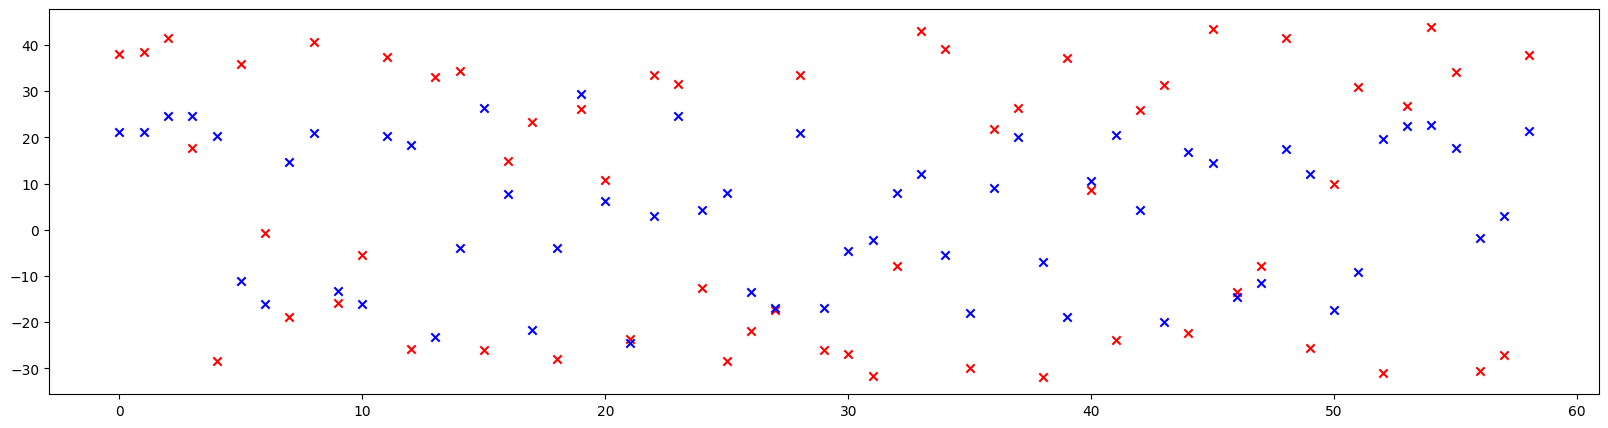

tensor(1.304173467684e+02, dtype=torch.float64)
tensor(1.234046991925e+02, dtype=torch.float64)



In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**10

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)[model.monitor_index]
print(trajectory.shape)
print()

# Set x & y coordinates at each monitor location

x = trajectory[..., 0]
y = trajectory[..., 2]

# Compute reference invariant values using selected trajectory

# Set trajectory index

index = 0

# Compute invariants

from harmonica.parameterization import invariant
action_x, action_y = invariant(model.out_normal[model.monitor_index[index]], trajectory[index])

print(f'{action_x.mean().item():>12.9e}, {action_x.std().item():>12.9e}')
print(f'{action_y.mean().item():>12.9e}, {action_y.std().item():>12.9e}')
print()

action_x = action_x.mean()
action_y = action_y.mean()

# Compare model and real beta function values

from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

cs_ax, cs_bx, cs_ay, cs_by = torch.stack([wolski_to_cs(w) for w in normal_to_wolski(model.out_normal)]).T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.size), 100*(cs_bx - model.bx)/model.bx, color='red', marker='x')
plt.scatter(range(model.size), 100*(cs_by - model.by)/model.by, color='blue', marker='x')
plt.show()

error_x = (cs_bx[model.monitor_index] - model.bx[model.monitor_index]).abs().sum()
error_y = (cs_by[model.monitor_index] - model.by[model.monitor_index]).abs().sum()

print(error_x)
print(error_y)
print()

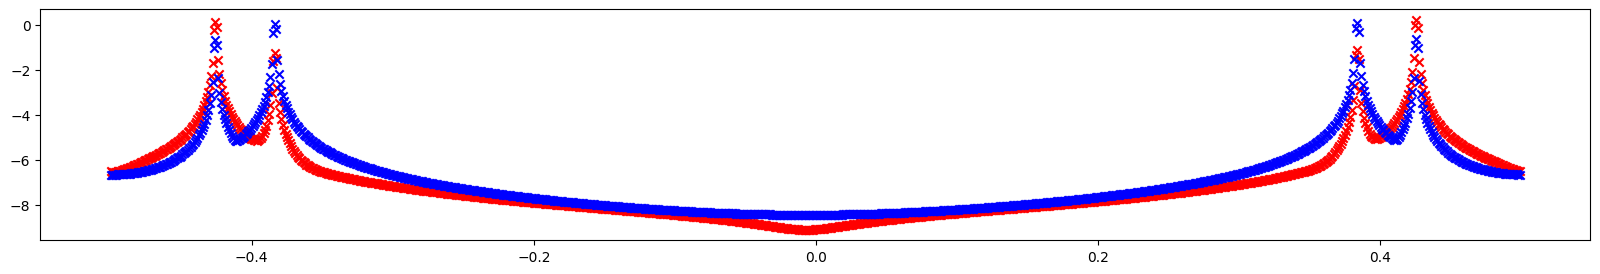

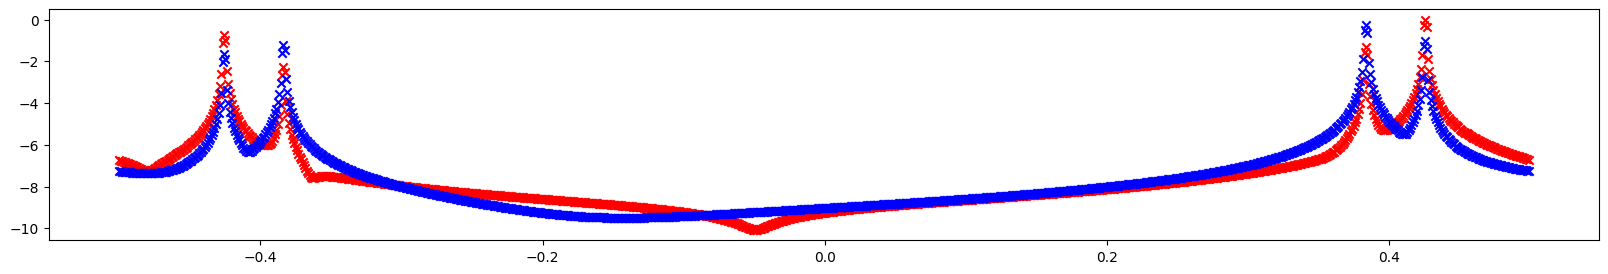

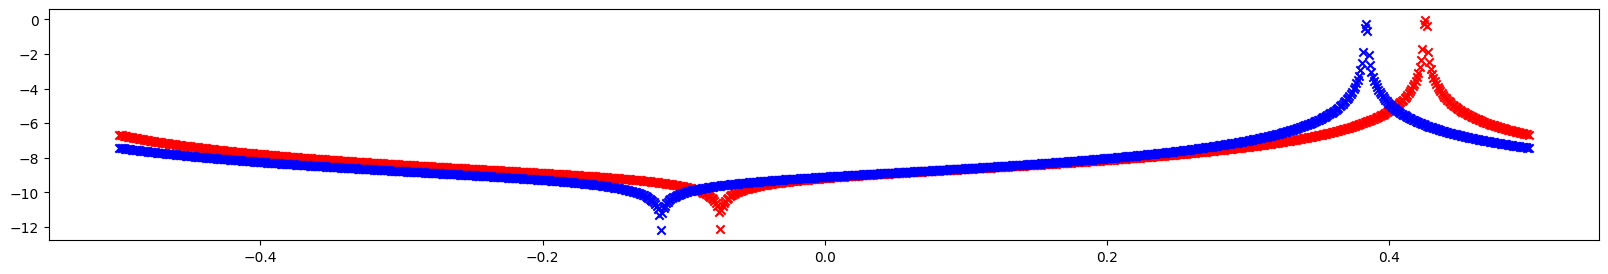

In [6]:
# For coupled case, each spectrum contains four peaks
# Main peak (nux or nuy in x or y), main mirror peak (-nux or -nuy in x or y)
# Coupling peak (nux or nuy in  in y or x), coupling mirror peak (-nux or -nuy in  in y or x)

window = Window.cosine_window(length, 1.0, dtype=dtype)

index = 0
orbit = trajectory[index].T
qx, px, qy, py = orbit
wx = (qx + 1j*px)*window
wy = (qy + 1j*py)*window

plt.figure(figsize=(20, 3))
plt.scatter(torch.fft.fftfreq(length), torch.fft.fft(wx).abs().log10().cpu().numpy(), color='red', marker='x')
plt.scatter(torch.fft.fftfreq(length), torch.fft.fft(wy).abs().log10().cpu().numpy(), color='blue', marker='x')
plt.show()

# Floquet coordinates contain only one main peak (if normalization is correct)

# Model normalization

normal = model.normal[model.monitor_index[index]]
qx, px, qy, py = normal.inverse() @ orbit
wx = (qx + 1j*px)*window
wy = (qy + 1j*py)*window

plt.figure(figsize=(20, 3))
plt.scatter(torch.fft.fftfreq(length), torch.fft.fft(wx).abs().log10().cpu().numpy(), color='red', marker='x')
plt.scatter(torch.fft.fftfreq(length), torch.fft.fft(wy).abs().log10().cpu().numpy(), color='blue', marker='x')
plt.show()

# Correct normalization

normal = model.out_normal[model.monitor_index[index]]
qx, px, qy, py = normal.inverse() @ orbit
wx = (qx + 1j*px)*window
wy = (qy + 1j*py)*window

plt.figure(figsize=(20, 3))
plt.scatter(torch.fft.fftfreq(length), torch.fft.fft(wx).abs().log10().cpu().numpy(), color='red', marker='x')
plt.scatter(torch.fft.fftfreq(length), torch.fft.fft(wy).abs().log10().cpu().numpy(), color='blue', marker='x')
plt.show()

In [7]:
# Instead of using FFT spectrum peak amplitudes, one can compute DTFT amplitudes for given four frequencies

# Fractional tunes

nux, nuy = mod(model.out_tune, 1)

# Mirror tunes

NUX, NUY = abs(mod(model.out_tune, 1, -0.5))

# Model normalization

normal = model.normal[model.monitor_index[index]]
qx, px, qy, py = normal.inverse() @ orbit
wx = (qx + 1j*px)*window
wy = (qy + 1j*py)*window

time = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

axx = (wx*torch.exp(1j*2.0*numpy.pi*nux*time)).sum().abs()
bxx = (wx*torch.exp(1j*2.0*numpy.pi*NUX*time)).sum().abs()
axy = (wx*torch.exp(1j*2.0*numpy.pi*nuy*time)).sum().abs()
bxy = (wx*torch.exp(1j*2.0*numpy.pi*NUY*time)).sum().abs()

ayy = (wy*torch.exp(1j*2.0*numpy.pi*nuy*time)).sum().abs()
byy = (wy*torch.exp(1j*2.0*numpy.pi*NUY*time)).sum().abs()
ayx = (wy*torch.exp(1j*2.0*numpy.pi*nux*time)).sum().abs()
byx = (wy*torch.exp(1j*2.0*numpy.pi*NUX*time)).sum().abs()

print(torch.stack([axx, bxx, axy, bxy]).cpu().numpy())
print(torch.stack([ayy, byy, ayx, byx]).cpu().numpy())
print(((bxx + axy + bxy)/axx + (byy + ayx + byx)/ayy).numpy())
print()


# Correct normalization

normal = model.out_normal[model.monitor_index[index]]
qx, px, qy, py = normal.inverse() @ orbit
wx = (qx + 1j*px)*window
wy = (qy + 1j*py)*window

time = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

axx = (wx*torch.exp(1j*2.0*numpy.pi*nux*time)).sum().abs()
bxx = (wx*torch.exp(1j*2.0*numpy.pi*NUX*time)).sum().abs()
axy = (wx*torch.exp(1j*2.0*numpy.pi*nuy*time)).sum().abs()
bxy = (wx*torch.exp(1j*2.0*numpy.pi*NUY*time)).sum().abs()

ayy = (wy*torch.exp(1j*2.0*numpy.pi*nuy*time)).sum().abs()
byy = (wy*torch.exp(1j*2.0*numpy.pi*NUY*time)).sum().abs()
ayx = (wy*torch.exp(1j*2.0*numpy.pi*nux*time)).sum().abs()
byx = (wy*torch.exp(1j*2.0*numpy.pi*NUX*time)).sum().abs()

print(torch.stack([axx, bxx, axy, bxy]).cpu().numpy())
print(torch.stack([ayy, byy, ayx, byx]).cpu().numpy())
print(((bxx + axy + bxy)/axx + (byy + ayx + byx)/ayy).numpy())
print()

[0.97729074 0.17683437 0.04771346 0.00516803]
[0.52680447 0.05838929 0.08989262 0.02231944]
0.5588956354662213

[9.65095498e-01 5.05400473e-08 3.03300979e-07 2.63376756e-08]
[5.25702869e-01 8.49233040e-09 1.65212868e-07 1.43465499e-08]
7.51643481085874e-07



In [8]:
# Set free normalization matrix elements

N11 = model.out_normal[:, 0, 0][model.monitor_index]
N33 = model.out_normal[:, 2, 2][model.monitor_index]
N21 = model.out_normal[:, 1, 0][model.monitor_index]
N43 = model.out_normal[:, 3, 2][model.monitor_index]
N13 = model.out_normal[:, 0, 2][model.monitor_index]
N31 = model.out_normal[:, 2, 0][model.monitor_index]
N14 = model.out_normal[:, 0, 3][model.monitor_index]
N41 = model.out_normal[:, 3, 0][model.monitor_index]

# Using eight free elements other elements of normalization matrix can be computed from symplectic condition
# Note, N12 and N34 are fixed to zero values

from harmonica.parameterization import parametric_normal
print(torch.allclose(model.out_normal[model.monitor_index], torch.stack([parametric_normal(*free) for free in torch.stack([N11, N33, N21, N43, N13, N31, N14, N41]).T])))

True


In [9]:
# Generate TbT data

# Set noise values for each monitor location 

noise_x = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x)
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y)
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


In [10]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=512, order=0.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

mqx= 0.574315292
nux= 0.574315295, sigma_nux=1.12423099e-07, error_nux=3.10299697e-09


In [11]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(mqy - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=512, order=0.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

mqy= 0.616331935
nuy= 0.616331922, sigma_nuy=1.65709277e-07, error_nuy=1.35326528e-08


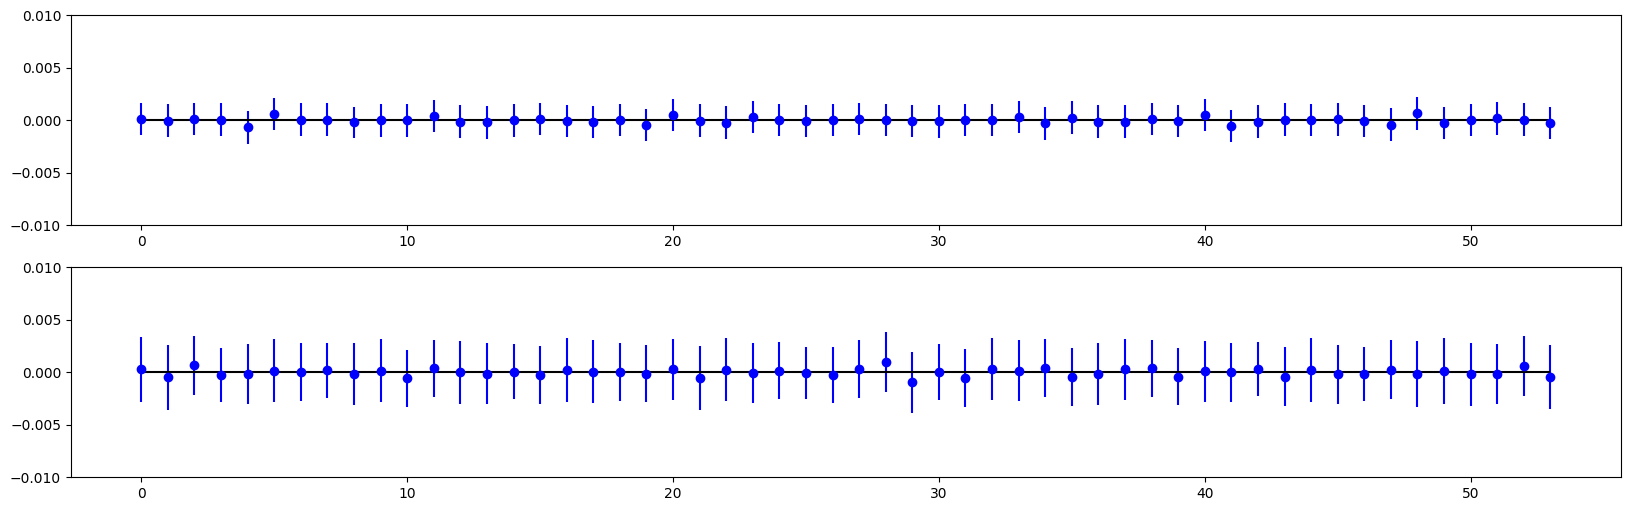

In [12]:
# Set table

table = Table(
    [name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'],
    nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    dtype=dtype, device=device)

# Compare phase advance between adjacent monitor locations

mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(mqx, mux)
muy, _ = Decomposition.phase_adjacent(mqy, muy)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x).cpu().numpy(), yerr=table.sigma_x.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y).cpu().numpy(), yerr=table.sigma_y.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

plt.show()

In [13]:
# Set twiss

twiss = Twiss(model, table)

In [14]:
%%time

# Estimate twiss from invariant fit (use first 256 turns and 512 random samples)

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1, 256, parametric_normal, model.matrix, count=512, verbose=False, n_jobs=12)
print(data.shape)

torch.Size([54, 2, 10, 512])
CPU times: user 1min 3s, sys: 2.4 s, total: 1min 5s
Wall time: 1min 53s


In [15]:
# Process fitted invariants

ix = data[:, 0, 0]
iy = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix, iy, sigma_ix, sigma_iy)

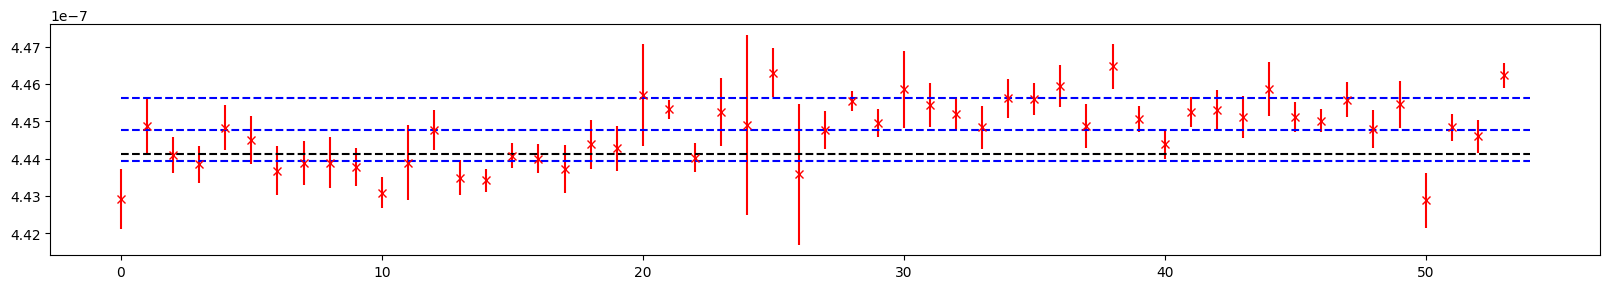

tensor(4.441305732231e-07, dtype=torch.float64)
tensor(4.447758991698e-07, dtype=torch.float64)
tensor(8.332137166102e-10, dtype=torch.float64)



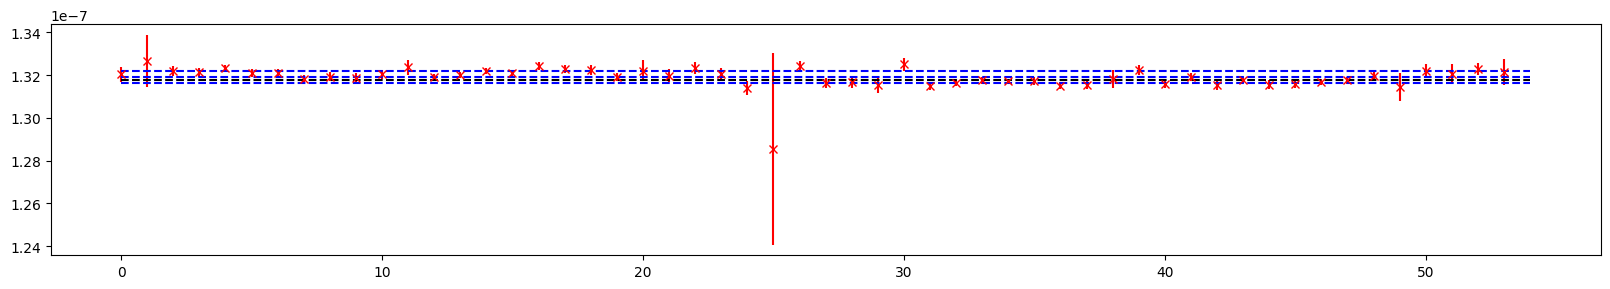

tensor(1.317803891460e-07, dtype=torch.float64)
tensor(1.319169741469e-07, dtype=torch.float64)
tensor(2.750752419061e-10, dtype=torch.float64)



In [16]:
# Plot invariants for each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_x, 0, 54, linestyles='dashed', color='black')
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, 54, linestyles='dashed', color='blue')
plt.show()

print(action_x)
print(invariant['ix_value'])
print(invariant['ix_error'])
print()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_y, 0, 54, linestyles='dashed', color='black')
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, 54, linestyles='dashed', color='blue')
plt.show()

print(action_y)
print(invariant['iy_value'])
print(invariant['iy_error'])
print()

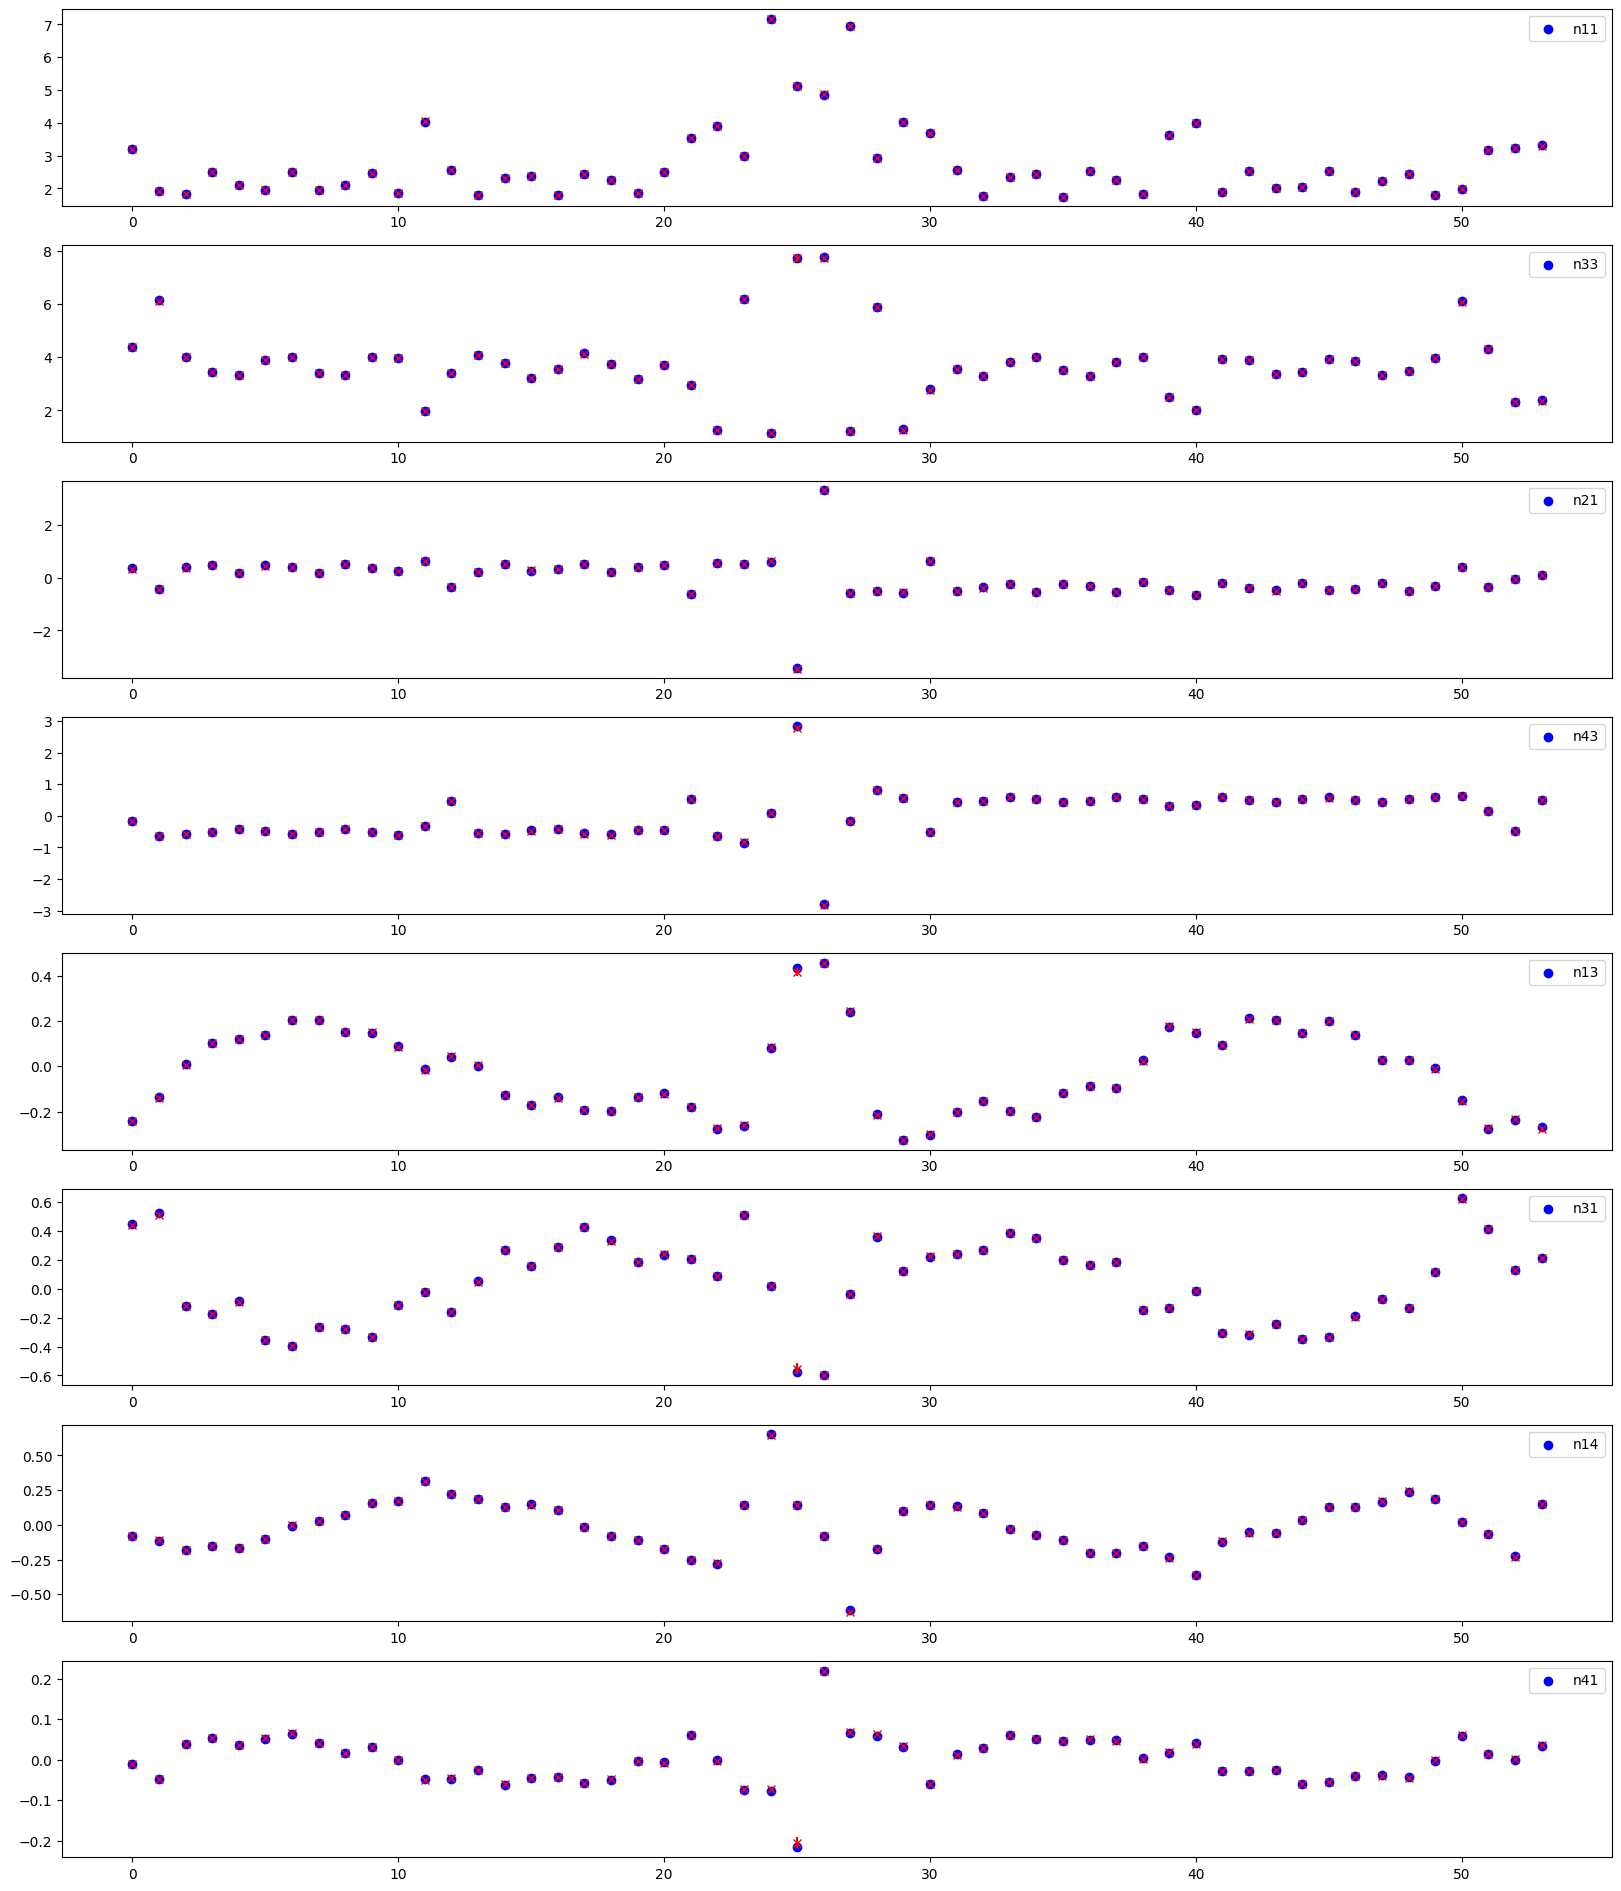

tensor(2.078271756985e-01, dtype=torch.float64)
tensor(2.541564713952e-01, dtype=torch.float64)
tensor(1.559942495366e-01, dtype=torch.float64)
tensor(2.063002487194e-01, dtype=torch.float64)
tensor(1.098523814252e-01, dtype=torch.float64)
tensor(1.200498457065e-01, dtype=torch.float64)
tensor(8.997011840444e-02, dtype=torch.float64)
tensor(7.722380623496e-02, dtype=torch.float64)


In [17]:
# Process twiss & compare

mask = invariant['ix_mask']*invariant['sx_mask']*invariant['iy_mask']*invariant['sy_mask']

value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11, mask=mask)
value_n33, error_n33 = twiss.process(value_n33, error_n33, mask=mask)
value_n21, error_n21 = twiss.process(value_n21, error_n21, mask=mask)
value_n43, error_n43 = twiss.process(value_n43, error_n43, mask=mask)
value_n13, error_n13 = twiss.process(value_n13, error_n13, mask=mask)
value_n31, error_n31 = twiss.process(value_n31, error_n31, mask=mask)
value_n14, error_n14 = twiss.process(value_n14, error_n14, mask=mask)
value_n41, error_n41 = twiss.process(value_n41, error_n41, mask=mask)

# Compare normalization matrix elements with exact values

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.monitor_count), N11, color='blue', marker='o', label='n11')
ax.errorbar(range(model.monitor_count), value_n11, yerr=error_n11, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(812)
ax.scatter(range(model.monitor_count), N33, color='blue', marker='o', label='n33')
ax.errorbar(range(model.monitor_count), value_n33, yerr=error_n33, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(813)
ax.scatter(range(model.monitor_count), N21, color='blue', marker='o', label='n21')
ax.errorbar(range(model.monitor_count), value_n21, yerr=error_n21, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(814)
ax.scatter(range(model.monitor_count), N43, color='blue', marker='o', label='n43')
ax.errorbar(range(model.monitor_count), value_n43, yerr=error_n43, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(815)
ax.scatter(range(model.monitor_count), N13, color='blue', marker='o', label='n13')
ax.errorbar(range(model.monitor_count), value_n13, yerr=error_n13, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(816)
ax.scatter(range(model.monitor_count), N31, color='blue', marker='o', label='n31')
ax.errorbar(range(model.monitor_count), value_n31, yerr=error_n31, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(817)
ax.scatter(range(model.monitor_count), N14, color='blue', marker='o', label='n14')
ax.errorbar(range(model.monitor_count), value_n14, yerr=error_n14, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(818)
ax.scatter(range(model.monitor_count), N41, color='blue', marker='o', label='n41')
ax.errorbar(range(model.monitor_count), value_n41, yerr=error_n41, fmt=' ', color='red', marker='x')
ax.legend()

plt.show()

print((N11 - value_n11).abs().sum())
print((N33 - value_n33).abs().sum())
print((N21 - value_n21).abs().sum())
print((N43 - value_n43).abs().sum())
print((N13 - value_n13).abs().sum())
print((N31 - value_n31).abs().sum())
print((N14 - value_n14).abs().sum())
print((N41 - value_n41).abs().sum())

In [18]:
%%time

# Estimate twiss from ratio
# Given max signal length to use (256), samples (with length equal to window length) are generated using start shift with given step (4)
# Errors for each sample are estimated from inverse Hessian diagonal

# Note, since samples are generated using shifts, they are highly correlated

# Note, given free elements, full normalization matrix can be computed
# And invariants can be estimated from transformed orbits
# This can be used to filter data from samples

from harmonica.parameterization import parametric_normal
window = Window.cosine_window(128, 1.0, dtype=dtype, device=device)
data = twiss.get_twiss_from_ratio(1, 256, window, nux, nuy, parametric_normal, model.matrix, step=4, verbose=False, n_jobs=12)
print(data.shape)

torch.Size([54, 2, 8, 33])
CPU times: user 14.6 s, sys: 502 ms, total: 15.1 s
Wall time: 1min 26s


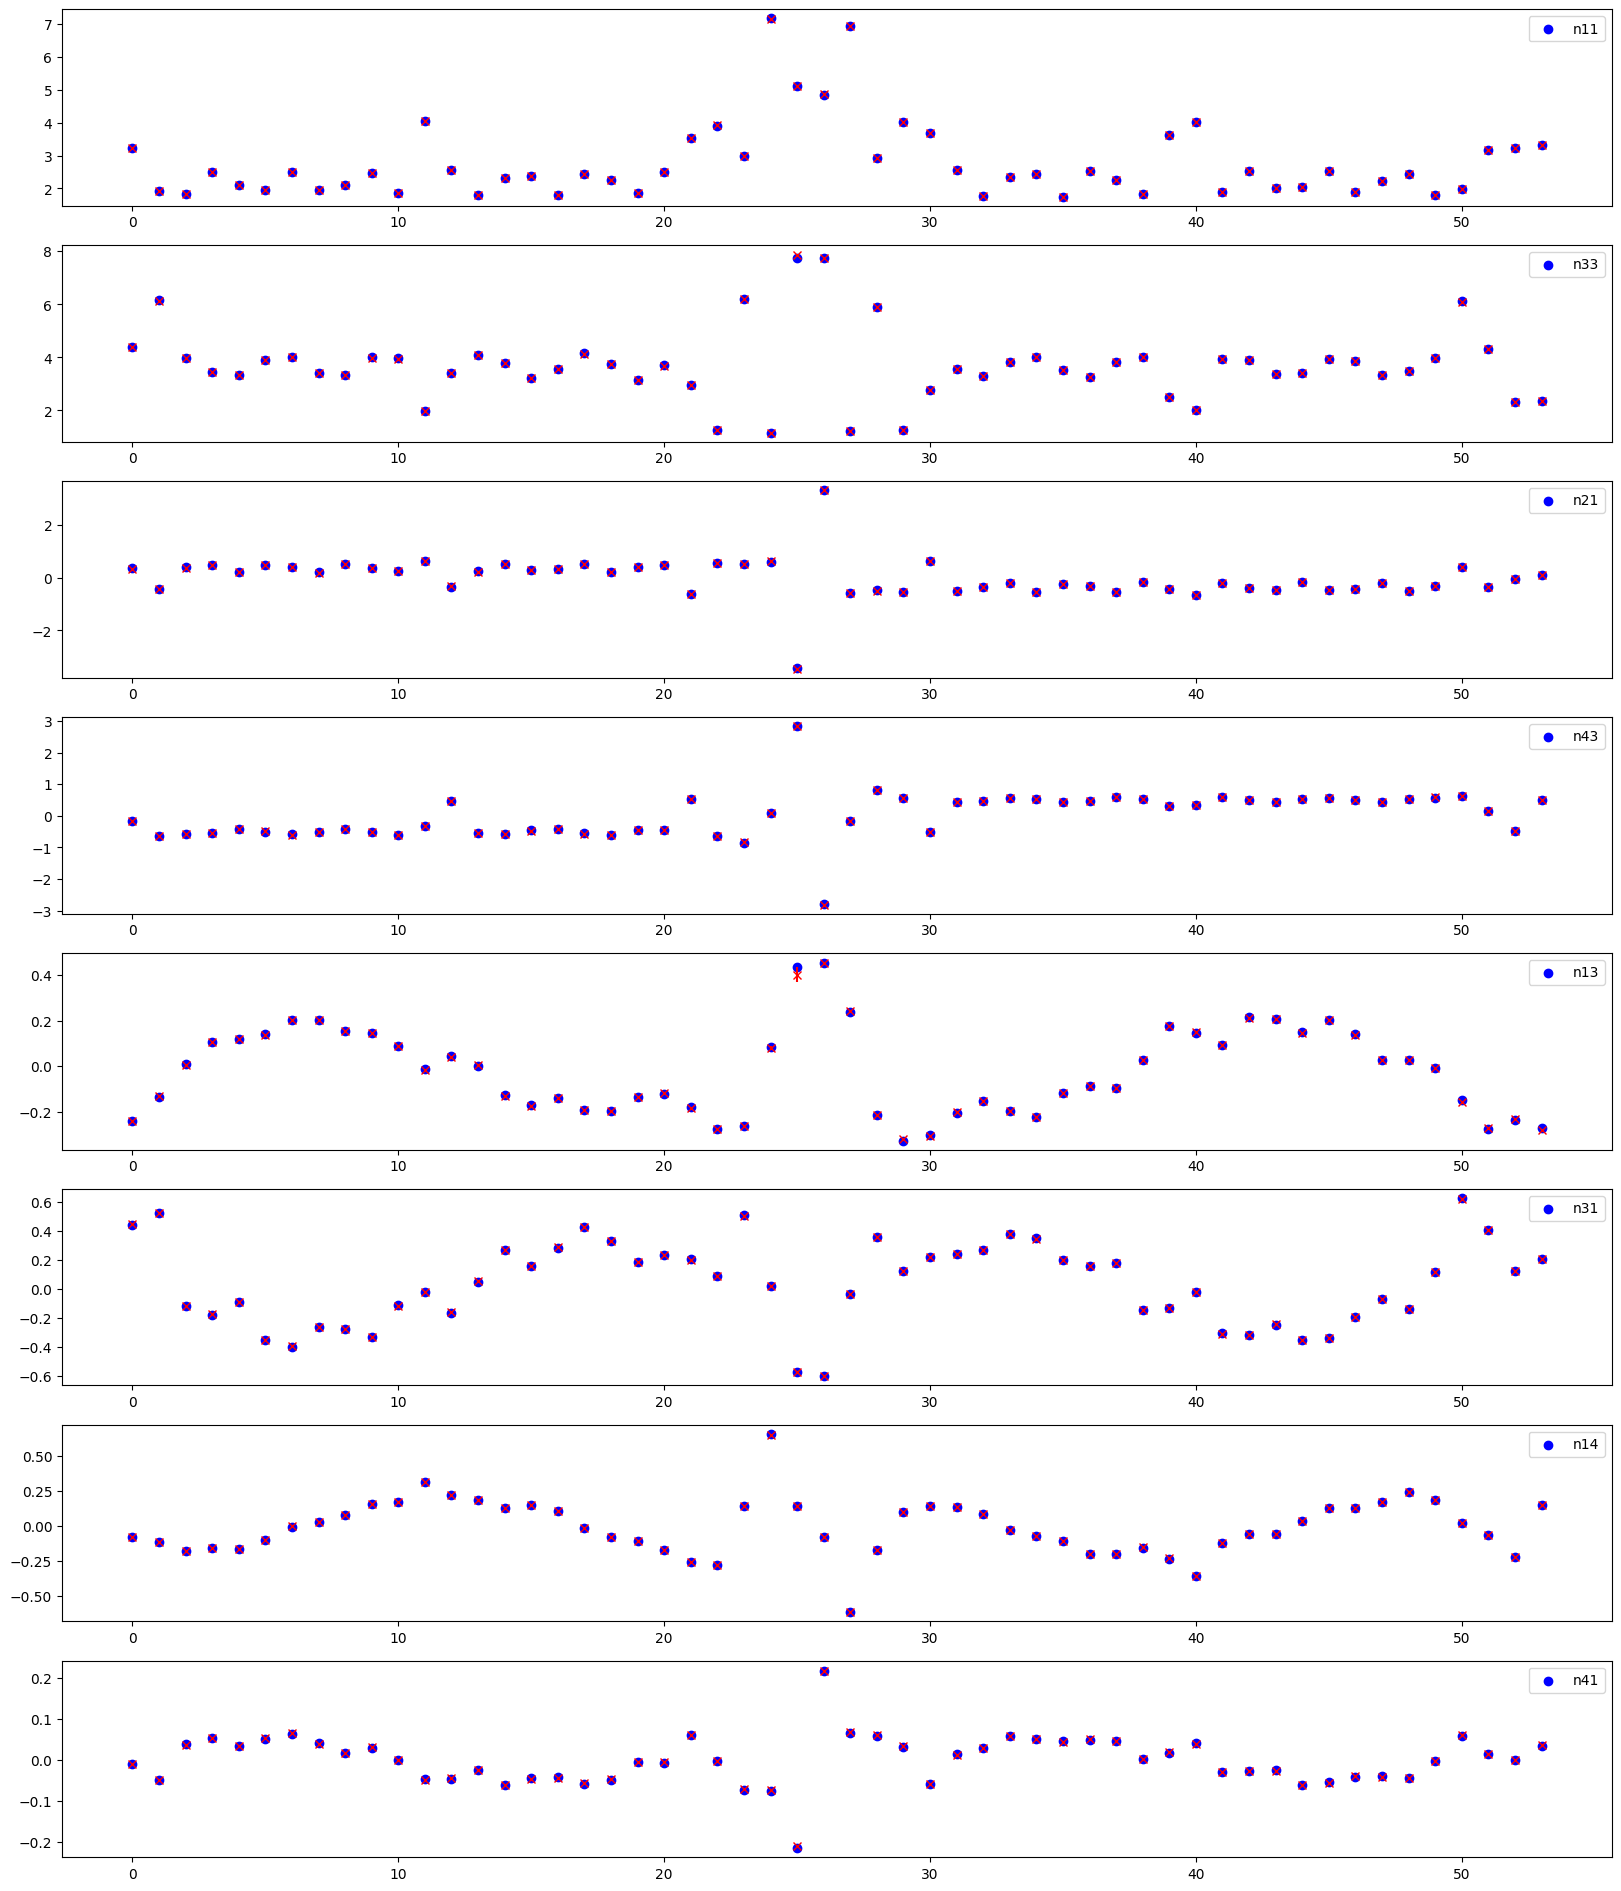

tensor(1.536837691972e-01, dtype=torch.float64)
tensor(2.968836902003e-01, dtype=torch.float64)
tensor(1.500212530286e-01, dtype=torch.float64)
tensor(1.711829242364e-01, dtype=torch.float64)
tensor(1.202851466195e-01, dtype=torch.float64)
tensor(6.298116440668e-02, dtype=torch.float64)
tensor(4.369300516571e-02, dtype=torch.float64)
tensor(6.713533055324e-02, dtype=torch.float64)


In [19]:
# Process twiss & compare

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

# Compare normalization matrix elements with exact values

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.monitor_count), N11, color='blue', marker='o', label='n11')
ax.errorbar(range(model.monitor_count), value_n11, yerr=error_n11, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(812)
ax.scatter(range(model.monitor_count), N33, color='blue', marker='o', label='n33')
ax.errorbar(range(model.monitor_count), value_n33, yerr=error_n33, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(813)
ax.scatter(range(model.monitor_count), N21, color='blue', marker='o', label='n21')
ax.errorbar(range(model.monitor_count), value_n21, yerr=error_n21, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(814)
ax.scatter(range(model.monitor_count), N43, color='blue', marker='o', label='n43')
ax.errorbar(range(model.monitor_count), value_n43, yerr=error_n43, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(815)
ax.scatter(range(model.monitor_count), N13, color='blue', marker='o', label='n13')
ax.errorbar(range(model.monitor_count), value_n13, yerr=error_n13, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(816)
ax.scatter(range(model.monitor_count), N31, color='blue', marker='o', label='n31')
ax.errorbar(range(model.monitor_count), value_n31, yerr=error_n31, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(817)
ax.scatter(range(model.monitor_count), N14, color='blue', marker='o', label='n14')
ax.errorbar(range(model.monitor_count), value_n14, yerr=error_n14, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(818)
ax.scatter(range(model.monitor_count), N41, color='blue', marker='o', label='n41')
ax.errorbar(range(model.monitor_count), value_n41, yerr=error_n41, fmt=' ', color='red', marker='x')
ax.legend()

plt.show()

print((N11 - value_n11).abs().sum())
print((N33 - value_n33).abs().sum())
print((N21 - value_n21).abs().sum())
print((N43 - value_n43).abs().sum())
print((N13 - value_n13).abs().sum())
print((N31 - value_n31).abs().sum())
print((N14 - value_n14).abs().sum())
print((N41 - value_n41).abs().sum())

In [20]:
%%time

# Twiss at virtual locations (from virtual orbits)
# Note, method='lstsq'

from harmonica.parameterization import parametric_normal
window = Window.cosine_window(128, 1.0, dtype=dtype, device=device)
data = twiss.get_twiss_from_ratio(1,
                                  256,
                                  window,
                                  nux,
                                  nuy,
                                  parametric_normal,
                                  model.matrix,
                                  method='lstsq',
                                  limit=2,
                                  phony=True,
                                  step=4,
                                  verbose=False,
                                  n_jobs=12)
print(data.shape)
print(model.virtual_count)

torch.Size([5, 2, 8, 33])
5
CPU times: user 1.1 s, sys: 51.9 ms, total: 1.15 s
Wall time: 6.93 s


In [21]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

In [22]:
# Compare with exact values

numpy.set_printoptions(linewidth=160)

from harmonica.parameterization import cs_normal

for index, location in enumerate(model.virtual_index):
    print(cs_normal(model.ax[location], model.bx[location], model.ay[location], model.by[location])[[0, 2, 1, 3, 0, 2, 0, 3], [0, 2, 0, 2, 2, 0, 3, 0]].cpu().numpy())
    print(torch.stack([value_n11[index], value_n33[index], value_n21[index], value_n43[index], value_n13[index], value_n31[index], value_n14[index], value_n41[index]]).cpu().numpy())
    print(model.out_normal[location][[0, 2, 1, 3, 0, 2, 0, 3], [0, 2, 0, 2, 2, 0, 3, 0]].cpu().numpy())
    print()

[ 2.73266554  3.98175692  0.24822713 -0.16435968  0.          0.          0.          0.        ]
[ 3.20936554  4.38155611  0.34941417 -0.15659053 -0.25424303  0.45117834 -0.08004829 -0.01180581]
[ 3.21105636  4.38450435  0.34767622 -0.15683424 -0.24152182  0.44367055 -0.07840291 -0.0110381 ]

[ 3.77337285  3.72233085 -0.51812134  0.74143651  0.          0.          0.          0.        ]
[ 4.47478381  4.15027742 -0.63667334  0.82288002 -0.33961446  0.41197732 -0.15182358  0.08642528]
[ 4.48694934  4.15426939 -0.63956462  0.82493074 -0.33823424  0.41364298 -0.14983666  0.08772656]

[ 8.66226410e-01  2.60206455e-01 -1.96353015e-13 -5.46137670e-14  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
[ 9.98761463e-01  2.85012739e-01 -8.42346526e-02 -2.17145898e-01  7.86613258e-02 -2.75072699e-02  1.72535244e-02  9.25677622e-05]
[ 1.0011377   0.28605411 -0.08598807 -0.4890788   0.07742569 -0.02667303  0.01853071  0.00108947]

[ 3.77337285  3.72233085  0.51812134 -0.74143651  0